# Set up directories 

## Setup

In this notebook, we will:

- Implement a fully vectorized loss function for the multiclass SVM.
- Derive and implement the fully vectorized analytical gradient.
- Verify the gradient implementation using numerical gradient checking.
- Use a validation set to tune the learning rate and regularization strength.
- Optimize the SVM objective using stochastic gradient descent (SGD).
- Visualize the final learned weight vectors for each class.

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# This prints the current working directory
import os
print('Current working directory: ', os.getcwd())

Current working directory:  /content


In [3]:
# You can use Linux commands like `pwd`, `cd` and `ls` to
# be sure about the path on which the Lab1 folder is
# Usually it should be in `/content/drive/MyDrive/labs/lab_1_2024_2025/`
# Also, make sure that the dataset cifar-10-batches-py is already downloaded!
!ls /content/drive/MyDrive/labs/

arrays	cifar-10-batches-py  lab_1_2024_2025  lab_2_2024_2025


In [ ]:
# Location path
FOLDERPATH = '/content/drive/MyDrive/labs/lab_1_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

In [ ]:
# Having downloaded the dataset, let's change to projct's directory
%cd {FOLDERPATH}

/content/drive/MyDrive/labs/lab_1_2024_2025


# Multiclass Support Vector Machine


## Set up code

In [6]:
# Run some setup code for this notebook.
import random
import numpy as np
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Pre-processing

In [13]:
from engine.data_utils import load_CIFAR10

# Load the raw CIFAR-10 data.
cifar10_dir = '/content/drive/MyDrive/labs/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


Check the type of X arrays.

In [8]:
print('The type of X_train array as loaded is {}'.format(X_train.dtype))
print('The type of X_test array as loaded is {}'.format(X_test.dtype))

The type of X_train array as loaded is float64
The type of X_test array as loaded is float64


Let's convert ``uint`` X arrays to ``float``. This is necessary for some computations that follow.

In [9]:
# Convert arrays uint8 -> float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

Check their type now!

In [10]:
print('The type of X_train array as loaded is {}'.format(X_train.dtype))
print('The type of X_test array as loaded is {}'.format(X_test.dtype))

The type of X_train array as loaded is float64
The type of X_test array as loaded is float64


Once our full dataset is loaded, we choose to store it in ``.npy`` files as we did in ``knn.ipynb``.

Recall that by this way we can easily load the dataset, in case our runtime crashes.

Apart from that, loading from ``.npy`` files is most of the times faster than loading from image files like ``.jpeg`` or ``.png``, as the latter needs some extra steps.

In [11]:
# First, let's create a new folder called arrays
# inside the labs directory. Specify dir:
# NOTICE: This directory should probably alredy exist!
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Create arrays directory
if not os.path.exists(arrays_dir):
    os.makedirs(arrays_dir)

# Save arrays in .npy files inside the new arrays dir
np.save(os.path.join(arrays_dir, 'full_X_train.npy'), X_train)
np.save(os.path.join(arrays_dir, 'full_y_train.npy'), y_train)
np.save(os.path.join(arrays_dir, 'full_X_test.npy'), X_test)
np.save(os.path.join(arrays_dir, 'full_y_test.npy'), y_test)

# Check that arrays are indeed saved
os.listdir(arrays_dir)

['full_X_train.npy',
 'full_y_train.npy',
 'full_X_test.npy',
 'full_y_test.npy',
 'X_train_knn.npy',
 'y_train_knn.npy',
 'y_test_knn.npy',
 'X_test_knn.npy']

Now that we have our dataset stored in .npy files, we can use the following coding snippet to easily load it back if needed.

## Load .npy files

In [12]:
# Specify labs dir again, so that arrays dir is
# automatically retrieved and arrays can be loaded from it
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Load arrays if needed. Uncomment to use!
X_train = np.load(os.path.join(arrays_dir, 'full_X_train.npy'))
y_train = np.load(os.path.join(arrays_dir, 'full_y_train.npy'))
X_test = np.load(os.path.join(arrays_dir, 'full_X_test.npy'))
y_test = np.load(os.path.join(arrays_dir, 'full_y_test.npy'))

# Num of samples for training and test
num_training = X_train.shape[0]
num_test = X_test.shape[0]

## Data visualization

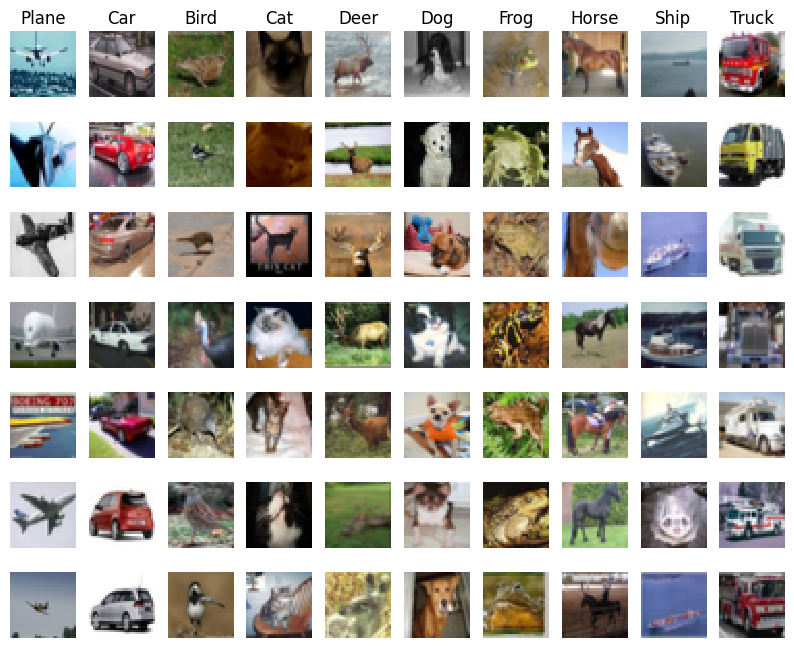

In [14]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls[:7])
plt.show()

## Split Data

Let's split our data!

In [15]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data.
# We can use this for development so our code runs faster.
num_training = 45000
num_validation = 5000
num_test = 10000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (45000, 32, 32, 3)
Train labels shape:  (45000,)
Validation data shape:  (5000, 32, 32, 3)
Validation labels shape:  (5000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


Let's reshape the data into row vectors (flattening).

In [16]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (45000, 3072)
Validation data shape:  (5000, 3072)
Test data shape:  (10000, 3072)
dev data shape:  (500, 3072)


## Pre-process data

Let's normalize our dataset.

Some of the elements of the mean image:
[130.81026667 136.10006667 132.57751111 130.21462222 135.4506
 131.84097778 131.12795556 136.25024444 132.56973333 131.65686667]
The mean image of our train set:


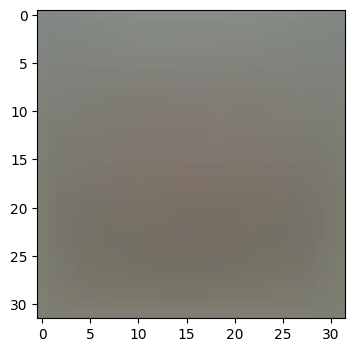

In [ ]:
# Preprocessing: subtract the mean image.

# Compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)

# Visualize some of its elements and the image itself
print('Some of the elements of the mean image:')
print(mean_image[:10]) # print a few of the elements
print('The mean image of our train set:')
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# Subtract the mean image from train and test data
mean_image = mean_image.astype('uint8')
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# Append the bias dimension of ones (i.e. bias trick) so that our SVM only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

Let's see our arrays' new shapes after bias trick.

In [18]:
print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

(45000, 3073) (5000, 3073) (10000, 3073) (500, 3073)


## SVM Classifier

### Forward and Backward (naive)

## Forward and Backward (naive)

We implement both the forward pass (computing the loss) and the backward pass (gradient computation) for the structured SVM loss function. We write our code inside the function `svm_loss_naive()` in `engine/classifiers/linear_svm.py`. The forward pass computes the SVM loss, and the backward pass computes the gradient of the loss with respect to the weights.

To implement the gradient, we use this:

$$
\nabla_{w_{y_i}} L_i = - \left( \sum_{j \neq y_i} \mathbf{1}(s_j - s_{y_i} + 1 > 0) \right)x_i,
$$

and

$$
\nabla_{w_j} L_i = \mathbf{1}(s_j - s_{y_i} + 1 > 0)x_i,
$$

where: $s_j = w_j^T x_i$, $s_{y_i} = w_{y_i}^T x_i$,

$\mathbf{1}$ is the indicator function that is **one** if the condition inside is **True**, or **zero** if the condition is **False**.

## Gradient Check

To verify that our computed gradient is correct, we use a technique called numerical gradient checking. This process involves estimating the gradient of the loss function by slightly perturbing the weights and measuring the resulting change in the loss. Then, we compare this numerically estimated gradient with the gradient you computed analytically.

Here is a breakdown of why and how we do this:

- **Analytic Gradient (Backward Pass):** The analytic gradient, which is computed in the `svm_loss_naive` function, is derived directly from the loss function using calculus. This method is efficient and exact in theory, but it can still be error-prone when implementing more complex functions.

- **Numerical Gradient:** The numerical gradient approximates the gradient by slightly perturbing each weight in `W` by a small value, usually called epsilon, and observing the resulting change in the loss. For a weight $W_{ij}$, the numerical gradient is computed as:

$$
\frac{\partial L}{\partial W_{ij}} \approx \frac{L(W + \epsilon) - L(W - \epsilon)}{2\epsilon}
$$

where $\epsilon$ is a small value, for example $10^{-5}$.

By comparing the analytic gradient with the numerical gradient, we can check whether the analytic implementation is correct. Small differences are expected due to numerical approximation errors, but large discrepancies usually indicate a mistake in the analytic gradient computation.

In [ ]:
# Once we've implemented the gradient, we recompute it with the code below.

# Generate a random SVM weight matrix of small numbers.

from engine.classifiers import svm_loss_naive
W = (np.random.rand(3073, 10) ) * 0.0001
reg = 0.00001




# Call the svm_loss_naive function
loss, grad = svm_loss_naive(W, X_dev, y_dev, reg)
print("Loss:", loss)
print("Gradient shape:", grad.shape)

# Compute the loss and its gradient at W.
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from engine.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# We do the gradient check once again with regularization turned on
loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

Loss: 9.064202043553342
Gradient shape: (3073, 10)
numerical: -27.512000 analytic: -27.512000, relative error: 1.526555e-11
numerical: 20.664000 analytic: 20.664000, relative error: 2.785194e-11
numerical: 0.506000 analytic: 0.506000, relative error: 3.840865e-10
numerical: -9.738000 analytic: -9.738000, relative error: 1.064720e-11
numerical: 5.846000 analytic: 5.846000, relative error: 2.293987e-11
numerical: 37.820000 analytic: 37.820000, relative error: 4.837308e-12
numerical: 4.476000 analytic: 4.476000, relative error: 2.736863e-12
numerical: 2.164000 analytic: 2.164000, relative error: 1.010819e-10
numerical: -0.544000 analytic: -0.544000, relative error: 8.796987e-10
numerical: 3.116000 analytic: 3.116000, relative error: 2.542297e-11
numerical: 18.493116 analytic: 18.493116, relative error: 9.556899e-12
numerical: 11.594662 analytic: 11.594662, relative error: 2.404747e-11
numerical: -0.308679 analytic: -0.308679, relative error: 4.807175e-10
numerical: -18.942580 analytic: -1

### Forward and Backward (vectorized)

We implement the SVM loss function, but this time use vector/matrix products/multiplications instead of loops. This vectorized version is inside the svm_loss_vectorized() function of engine/classifiers/linear_svm.py.

Inputs and outputs are the same as in svm_loss_naive.

In [20]:
# Next implement the function svm_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
import time

tic = time.time()
loss_naive, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from engine.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
loss_vectorized, _ = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 9.064202e+00 computed in 0.110478s
Vectorized loss: 9.064202e+00 computed in 0.011608s
difference: -0.000000


We complete the implementation of svm_loss_vectorized() by computing the gradient of the loss function in a vectorized way.

In [ ]:
# we complete the implementation of svm_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.099244s
Vectorized loss and gradient: computed in 0.009571s
difference: 0.000000


### Stochastic Gradient Descent

We have vectorized and efficient expressions for the loss and the gradient.

Our gradient matches the numerical gradient.

We are therefore ready to use Stochastic Gradient Descent (SGD) to minimize the loss.

Our code for this part will be written inside engine/classifiers/linear_classifier.py. Inside its LinearClassifier.train() function, we implement SGD.

In [ ]:
# In the file linear_classifier.py, we implement SGD in the function
# LinearClassifier.train() and then we run it with the code below.
from engine.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 787.509654
iteration 100 / 1500: loss 286.897270
iteration 200 / 1500: loss 107.026217
iteration 300 / 1500: loss 43.151030
iteration 400 / 1500: loss 19.114865
iteration 500 / 1500: loss 9.723788
iteration 600 / 1500: loss 6.908900
iteration 700 / 1500: loss 5.667447
iteration 800 / 1500: loss 5.807007
iteration 900 / 1500: loss 5.069162
iteration 1000 / 1500: loss 4.868728
iteration 1100 / 1500: loss 5.375975
iteration 1200 / 1500: loss 4.957947
iteration 1300 / 1500: loss 6.065347
iteration 1400 / 1500: loss 5.152250
That took 9.389413s


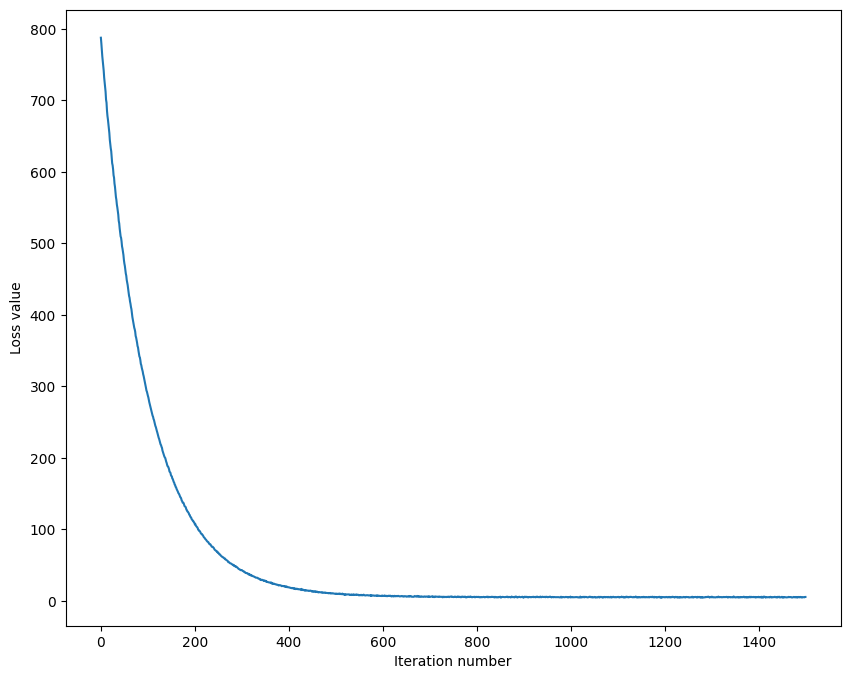

In [24]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

### Predict



Inside the `engine/classifiers/linear_classifier.py`, we write the ``LinearClassification.predict()`` function to evaluate the performance of the model.

In [25]:
# Write the LinearClassification.predict function
# and evaluate the performance on both the training and validation set
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.371200
validation accuracy: 0.363200


### Hyperparameter search

Now, we write code that chooses the best hyperparameters by tuning on the validation set (grid search).

Our goal is to perform a real-world training in order to save the SVM mobel that performs the best on validation set.

In [ ]:
# We use the validation set to tune hyperparameters (regularization strength and
# learning rate). We should experiment with different ranges for the learning
# rates and regularization strengths; if we are careful we should be able to
# get a classification accuracy of about 0.39 on the validation set.

# we may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_svm = None # The LinearSVM object that achieved the highest validation rate.


                                                                       #
# We write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a linear SVM on the      #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the LinearSVM object that achieves this  #
# accuracy in best_svm.                                                        

# Provided as a reference. You may or may not want to change these hyperparameters
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
  for reg in regularization_strengths:
    svm = LinearSVM()
    svm.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500, batch_size=200, verbose=False)

    train_accuracy = np.mean(svm.predict(X_train) == y_train)
    val_accuracy = np.mean(svm.predict(X_val) == y_val)
    results[(lr, reg)] = (train_accuracy, val_accuracy)

    if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm


# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during validation: %f' % best_val)

/content/drive/MyDrive/labs/lab_1_2024_2025/engine/classifiers/linear_svm.py:101: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/content/drive/MyDrive/labs/lab_1_2024_2025/engine/classifiers/linear_svm.py:101: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
/content/drive/MyDrive/labs/lab_1_2024_2025/engine/classifiers/linear_svm.py:121: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
/content/drive/MyDrive/labs/lab_1_2024_2025/engine/classifiers/linear_classifier.py:83: RuntimeWarning: invalid value encountered in subtract
  self.W -= learning_rate * grad


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.366244 val accuracy: 0.359000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.362533 val accuracy: 0.356600
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.077089 val accuracy: 0.078200
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.100156 val accuracy: 0.098600
best validation accuracy achieved during validation: 0.359000


### Visualization of search results

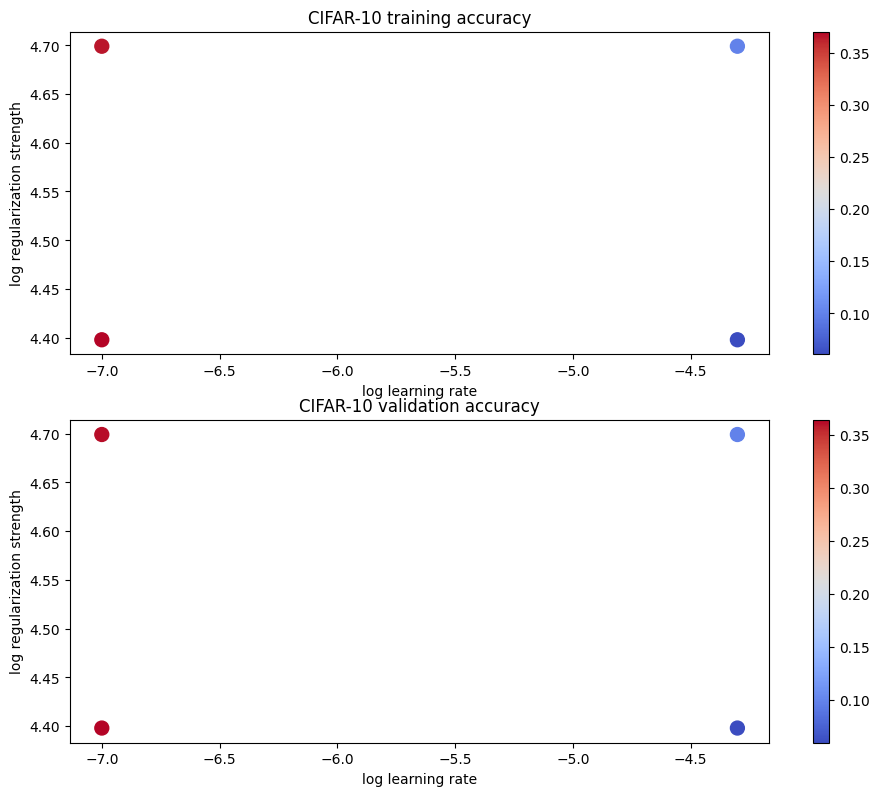

In [ ]:
# Visualize the results
import math

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

### Predict on test set (unseen images)

Let's see how our model performs on unseen images - the test set.

In [ ]:
# Evaluate the best svm on test set
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)

Linear SVM on raw pixels final test set accuracy: 0.368100


### Visualization of learned weights for each class

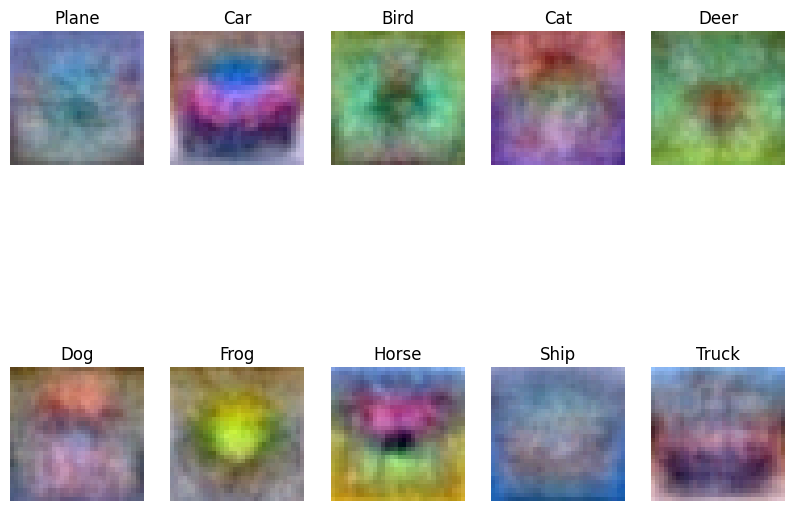

In [ ]:
# Visualize the learned weights for each class.
w = best_svm.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

The model learns 10 weight vectors, which matches the number of CIFAR-10 classes. Each weight vector can be interpreted as a rough template of the visual patterns that the classifier associates with a specific class.

From the visualization above, some common class-related patterns can be observed, although not very clearly. For example, certain shape-like structures are somewhat visible for classes such as horse, car, and deer, while color patterns are more noticeable for classes such as frog, ship, and airplane.

In general, the goal of an SVM is to find decision boundaries that maximize the margin between classes. However, like k-NN, this approach is still limited when applied directly to raw image pixels. It mainly relies on low-level pixel information and cannot capture deeper semantic meaning from images.

Therefore, although SVMs can be effective for many types of data, raw image classification usually requires more suitable architectures. Models such as convolutional neural networks are better able to learn meaningful visual features and are more appropriate for image classification tasks.